## Test code and functions for this project here

In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import csv
import pandas as pd
import os

## Simulating 2D UAV motion with Motion Model Equations 



First few rows of the simulation log:
     t        x_true  y_true       psi    v  a_cmd  omega_cmd    x_meas  \
0  0.0  3.061617e-17    -4.5  1.570796  5.0    0.0        0.0 -0.125212   
1  0.1  6.123234e-17    -4.0  1.570796  5.0    0.0        0.0 -0.680302   
2  0.2  9.184851e-17    -3.5  1.570796  5.0    0.0        0.0  0.185735   
3  0.3  1.224647e-16    -3.0  1.570796  5.0    0.0        0.0 -0.455001   
4  0.4  1.530808e-16    -2.5  1.570796  5.0    0.0        0.0  0.588025   

     y_meas  
0 -4.794971  
1 -3.859455  
2 -3.782244  
3 -2.890058  
4 -2.462423  

Saved simulation log to: simulation_log/trajectory_log.csv


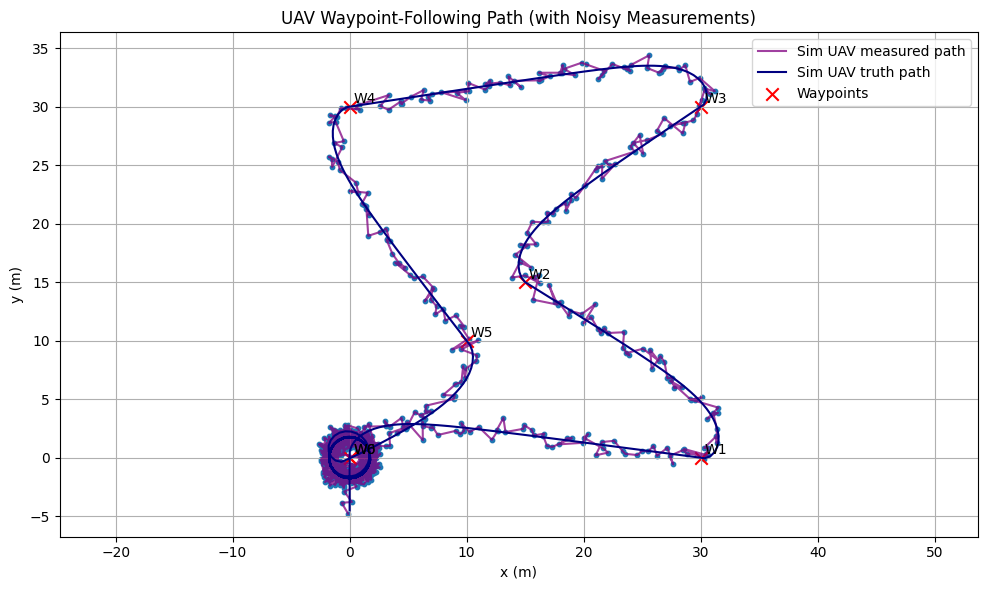

In [23]:

# 1. Define the UAV state model

class UAVState:
    """
    Simple 2D kinematic UAV model.
    State vector: [x, y, psi, v]
        x, y : position in world frame [m]
        psi  : heading angle [rad]
        v    : forward speed [m/s]
    """
    def __init__(self, x=0.0, y=0.0, psi=0.0, v=5.0):
        # Initialize state variables
        self.x = x
        self.y = y
        self.psi = psi
        self.v = v

    def as_array(self):
        """
        Return the state as a NumPy array.
        Useful later for Kalman filter/state-space code.
        """
        return np.array([self.x, self.y, self.psi, self.v])

    def step(self, a, omega, dt):
        """
        Advance the state forward by one time step using
        simple kinematic equations.

        a     : commanded forward acceleration [m/s^2]
        omega : commanded yaw rate [rad/s]
        dt    : time step [s]
        """
        # Position update: move forward in the direction of heading psi
        self.x   += self.v * math.cos(self.psi) * dt
        self.y   += self.v * math.sin(self.psi) * dt

        # Heading update: integrate yaw rate
        self.psi += omega * dt

        # Speed update: integrate acceleration
        self.v   += a * dt



# 2. Simulation configuration


dt = 0.1        # Time step [s]
steps = 800     # Total number of simulation steps

# Define a set of waypoints the UAV will try to follow
# Waypoints are in world coordinates (x, y) [m]
waypoints = [
    (0.0, 0.0),
    (30.0, 0.0),
    (15.0, 15.0),
    (30.0, 30.0),
    (0.0, 30.0),
    (10.0, 10.0),
    (0.0, 0.0)   # Back to start (square path)
]

# Initial state of the UAV
# Start slightly below the first waypoint, facing upward (90 deg)
state = UAVState(
    x=0.0,
    y=-5.0,
    psi=math.radians(90),  # Convert 90 degrees to radians
    v=5.0
)

# Control gains for a very simple guidance + speed control
k_psi = 2.0        # Heading control gain (how aggressively we turn toward the waypoint)
k_v   = 0.5        # Speed control gain
v_des = 5.0        # Desired speed [m/s]


# 3. Logging variables

# These lists collect data at each time step so we
# can save to CSV and/or use it in a Kalman Filter later.

ts = []            # Time stamps

# True (noise-free) state history
xs_true = []
ys_true = []
psis    = []
vs      = []

# Control input history
as_cmd     = []    # commanded accelerations
omegas_cmd = []    # commanded yaw rates

# Noisy measurements (what a GPS-like sensor might see)
xs_meas = []
ys_meas = []

# Waypoint management
current_wp = 0     # Index of the current waypoint
wp_tol = 0.5       # Distance threshold to "reach" a waypoint [m]



# 4. Main simulation loop


for k in range(steps):

    # Current simulation time
    t = k * dt

    # Get current waypoint
    wp_x, wp_y = waypoints[current_wp]

    # Vector from UAV to waypoint
    dx = wp_x - state.x
    dy = wp_y - state.y

    # Distance to waypoint
    dist_to_wp = math.hypot(dx, dy)  # same as sqrt(dx^2 + dy^2)

    # Check if we've reached the current waypoint
    # If yes, move to the next one (if it exists)
    if dist_to_wp < wp_tol and current_wp < len(waypoints) - 1:
        current_wp += 1
        wp_x, wp_y = waypoints[current_wp]
        dx = wp_x - state.x
        dy = wp_y - state.y

    # Desired heading angle from current position to waypoint
    desired_psi = math.atan2(dy, dx)  # gives angle in [-pi, pi]

    # Heading error (difference between where we want to face and current heading)
    err_psi = desired_psi - state.psi

    # Wrap heading error into [-pi, pi] to avoid large jumps
    err_psi = (err_psi + math.pi) % (2 * math.pi) - math.pi

    # Simple proportional (P) controller for yaw rate
    omega = k_psi * err_psi

    # Simple proportional controller for speed toward desired speed
    a = k_v * (v_des - state.v)

    # Step the true dynamics of the UAV using the control inputs
    state.step(a, omega, dt)


    # Add measurement noise for x and y
    # This simulates a noisy position sensor like GPS.
    # Mean = 0, std dev = 0.5 m
    noise_x = np.random.normal(0.0, 0.5)
    noise_y = np.random.normal(0.0, 0.5)

    x_meas = state.x + noise_x
    y_meas = state.y + noise_y


    # Logging
    ts.append(t)

    xs_true.append(state.x)
    ys_true.append(state.y)
    psis.append(state.psi)
    vs.append(state.v)

    as_cmd.append(a)
    omegas_cmd.append(omega)

    xs_meas.append(x_meas)
    ys_meas.append(y_meas)



# 5. Save log to CSV for EKF use

# Make sure the output folder exists
os.makedirs("simulation_log", exist_ok=True)

# Build a pandas DataFrame with all the logged data
df = pd.DataFrame({
    "t": ts,               # time
    "x_true": xs_true,     # true x
    "y_true": ys_true,     # true y
    "psi": psis,           # true heading
    "v": vs,               # true speed
    "a_cmd": as_cmd,       # commanded acceleration
    "omega_cmd": omegas_cmd,  # commanded yaw rate
    "x_meas": xs_meas,     # noisy x measurement
    "y_meas": ys_meas      # noisy y measurement
})

print("First few rows of the simulation log:")
print(df.head())

csv_path = "simulation_log/trajectory_log.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved simulation log to: {csv_path}")


# 6. Plotting the trajectory

plt.figure(figsize=(10, 6))

# Plot noisy measured path (what a GPS would see)
plt.plot(xs_meas, ys_meas, label="Sim UAV measured path",color="purple", linestyle="-", alpha=0.75)
plt.plot(xs_true, ys_true, label="Sim UAV truth path",color="navy", linestyle="-", alpha=1)
plt.scatter(xs_meas, ys_meas, s=10)

# Plot waypoints
wps_x, wps_y = zip(*waypoints)
plt.scatter(wps_x, wps_y, marker='x', s=80, color='r', label="Waypoints")

# Annotate each waypoint
for i, (wx, wy) in enumerate(waypoints):
    plt.text(wx + 0.3, wy + 0.3, f"W{i}", fontsize=10)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("UAV Waypoint-Following Path (with Noisy Measurements)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Trajectory is a nonlinear path and must use an EKF instead of a standard KF

#### Helper functions

In [3]:
# Cell 2: load data

# adjust path if needed
df = pd.read_csv("simulation_log/trajectory_log.csv")

print(df.head())
print("\nColumns:", df.columns.tolist())

# Extract numpy arrays
t       = df["t"].values          # time [s]
x_true  = df["x_true"].values     # ground-truth x
y_true  = df["y_true"].values     # ground-truth y
x_meas  = df["x_meas"].values     # noisy x
y_meas  = df["y_meas"].values     # noisy y

print("\nLengths:", len(t), len(x_meas), len(y_meas))

     t        x_true  y_true       psi    v  a_cmd  omega_cmd    x_meas  \
0  0.0  3.061617e-17    -4.5  1.570796  5.0    0.0        0.0  0.652283   
1  0.1  6.123234e-17    -4.0  1.570796  5.0    0.0        0.0 -0.542120   
2  0.2  9.184851e-17    -3.5  1.570796  5.0    0.0        0.0  0.073630   
3  0.3  1.224647e-16    -3.0  1.570796  5.0    0.0        0.0 -0.153351   
4  0.4  1.530808e-16    -2.5  1.570796  5.0    0.0        0.0  0.184933   

     y_meas  
0 -4.335613  
1 -4.654693  
2 -3.781042  
3 -4.065790  
4 -3.251650  

Columns: ['t', 'x_true', 'y_true', 'psi', 'v', 'a_cmd', 'omega_cmd', 'x_meas', 'y_meas']

Lengths: 800 800 800


In [4]:
# Cell 4: define model matrices (functions because dt changes)

def state_transition_matrix(dt: float) -> np.ndarray:
    """
    F(dt) for constant-velocity model:
    [1 0 dt  0]
    [0 1  0 dt]
    [0 0  1  0]
    [0 0  0  1]
    """
    F = np.array([
        [1.0, 0.0, dt, 0.0],
        [0.0, 1.0, 0.0, dt],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ])
    return F

def measurement_matrix() -> np.ndarray:
    """
    H for measuring position only:
    [1 0 0 0]
    [0 1 0 0]
    """
    H = np.array([
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
    ])
    return H

H = measurement_matrix()

#### Initialization

In [5]:
# Cell 5: noise covariances & initial conditions

# Measurement noise: sigma ≈ 10 m
sigma_meas = 0.5
R = np.array([
    [sigma_meas**2, 0.0],
    [0.0, sigma_meas**2],
])

# Process noise: tune these
#   small for position, larger for velocity
q_pos = 0.1
q_vel = 1.0
Q = np.diag([q_pos, q_pos, q_vel, q_vel])

# Initial state: start near first measurement
x0 = x_meas[0]
y0 = y_meas[0]

# Rough initial velocity estimate from first two points (or set to 0)
if len(t) >= 2:
    dt0 = max(t[1] - t[0], 1e-6)
    vx0 = (x_meas[1] - x_meas[0]) / dt0
    vy0 = (y_meas[1] - y_meas[0]) / dt0
else:
    vx0 = 0.0
    vy0 = 0.0

x_hat = np.array([x0, y0, vx0, vy0], dtype=float)

# Initial covariance: large uncertainty
P = np.diag([100.0, 100.0, 100.0, 100.0])

print("Initial state x_hat0:", x_hat)
print("Initial covariance P0:\n", P)

Initial state x_hat0: [  0.65228293  -4.33561305 -11.94402828  -3.19080443]
Initial covariance P0:
 [[100.   0.   0.   0.]
 [  0. 100.   0.   0.]
 [  0.   0. 100.   0.]
 [  0.   0.   0. 100.]]


#### Main filter Loop

In [6]:
# Cell 6: run the filter

N = len(t)

# storage for filtered states
x_filt_hist = np.zeros((N, 4))  # [x, y, vx, vy] at each step

# save initial state
x_filt_hist[0, :] = x_hat

for k in range(1, N):
    # 1) time step
    dt = t[k] - t[k-1]
    dt = float(dt)
    if dt <= 0:
        dt = 1e-6  # avoid zero / negative dt just in case

    F = state_transition_matrix(dt)

    # 2) PREDICTION STEP
    # x_pred = F x_prev
    x_pred = F @ x_hat

    # P_pred = F P F^T + Q
    P_pred = F @ P @ F.T + Q

    # 3) MEASUREMENT UPDATE
    z_k = np.array([x_meas[k], y_meas[k]])

    # innovation / residual
    y_k = z_k - (H @ x_pred)

    # innovation covariance
    S_k = H @ P_pred @ H.T + R

    # Kalman gain
    K_k = P_pred @ H.T @ np.linalg.inv(S_k)

    # updated state
    x_hat = x_pred + K_k @ y_k

    # updated covariance
    I = np.eye(4)
    P = (I - K_k @ H) @ P_pred

    # store
    x_filt_hist[k, :] = x_hat

# Extract filtered positions
x_filt = x_filt_hist[:, 0]
y_filt = x_filt_hist[:, 1]
vx_filt = x_filt_hist[:, 2]
vy_filt = x_filt_hist[:, 3]

print("Finished filtering.")

Finished filtering.


#### After the loop: using the results

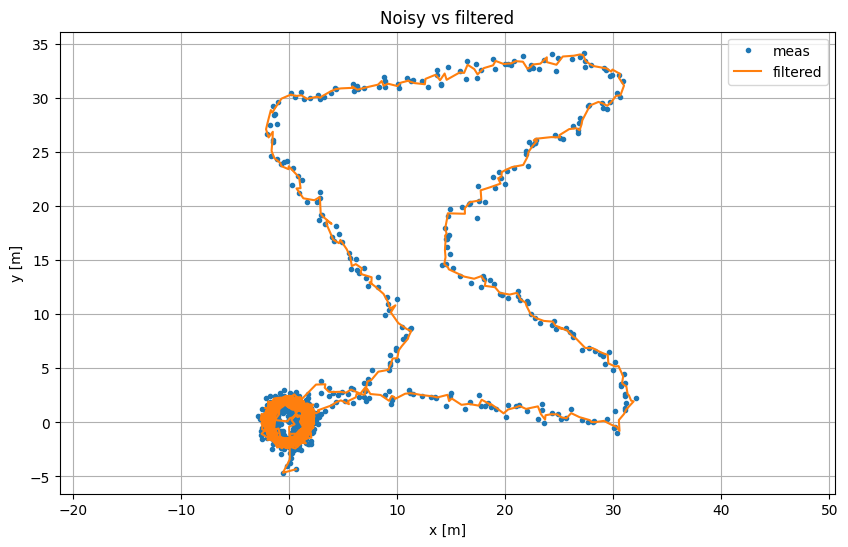

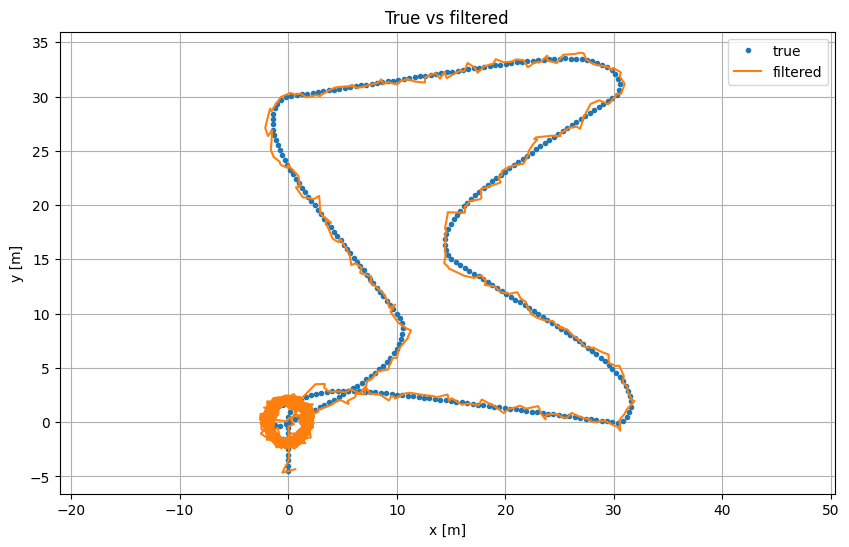

In [7]:
# Cell 7: trajectory comparison

plt.figure(figsize=(10,6))
# plt.plot(x_true, y_true, label="true")
plt.plot(x_meas, y_meas, marker=".", linestyle="none", label="meas")
plt.plot(x_filt, y_filt, label="filtered")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("Noisy vs filtered")
plt.axis("equal")
plt.grid()
plt.show()


plt.figure(figsize=(10,6))
plt.plot(x_true, y_true, marker=".", linestyle="none", label="true")
plt.plot(x_filt, y_filt, label="filtered")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("True vs filtered")
plt.axis("equal")
plt.grid()
plt.show()

#### Big-picture structure (EKF skeleton)

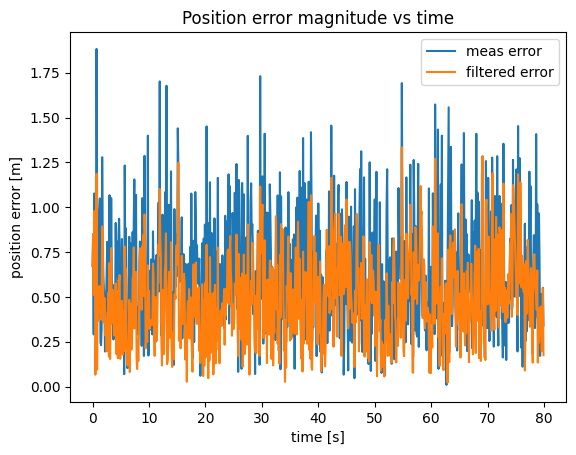

Mean measurement error: 0.6241142812289016
Mean filtered error   : 0.4904714997710957


In [8]:
# Cell 8: position error over time

err_meas = np.sqrt((x_meas - x_true)**2 + (y_meas - y_true)**2)
err_filt = np.sqrt((x_filt - x_true)**2 + (y_filt - y_true)**2)

plt.figure()
plt.plot(t, err_meas, label="meas error")
plt.plot(t, err_filt, label="filtered error")
plt.xlabel("time [s]")
plt.ylabel("position error [m]")
plt.legend()
plt.title("Position error magnitude vs time")
plt.show()

print("Mean measurement error:", np.mean(err_meas))
print("Mean filtered error   :", np.mean(err_filt))

### Reading and converting the AERPAW data 

In [9]:

# Load
df = pd.read_csv("AERPAW data/40m1.25MHz7.15.24.csv")

# Remove invalid GPS rows and time stamps
df = df[(df["GTLatitude"] != 0) & (df["GTLongitude"] != 0) & (df["Time"] != 0)]



# Filter ~40 m altitude
df40 = df[(df["GTAltitude"] >= 39.5) & (df["GTAltitude"] <= 40.5)]
time = df40["Time"].values   # not df["Time"] as lat/long and time will be different sizes

# Convert degrees → radians
lat = np.radians(df40["GTLatitude"].values)
lon = np.radians(df40["GTLongitude"].values)


# HH:MM:SS to seconds|sourced from: https://stackoverflow.com/questions/6402812/how-to-convert-an-hmmss-time-string-to-seconds-in-python
def get_sec(time_str):
    """Get seconds from time."""
    h, m, s = time_str.split(':')
    return int(h) * 3600 + int(m) * 60 + int(s)
# run the loop for the whole range of the time list/array
time_int = get_sec(time[0])
time_secs = []

for i in range(len(time)):
    n = get_sec(time[i])-time_int
    time_secs.append(n)

print("time len:", len(time_secs))
print("lat long len:", len(lat))



lat0 = lat[0]
lon0 = lon[0]
R = 6378137.0

x_true = R * (lon - lon0) * np.cos(lat0)
y_true = R * (lat - lat0)
z_true = df40["GTAltitude"].values

# adding guassian noise 
# standard deviations for measurement noise
sigma_x = 10.0   # meters
sigma_y = 10.0   # meters


# Add Gaussian noise to create fake "GPS measurements"
x_meas = x_true + np.random.normal(0, sigma_x, size=len(x_true))
y_meas = y_true + np.random.normal(0, sigma_y, size=len(y_true))




time len: 222
lat long len: 222


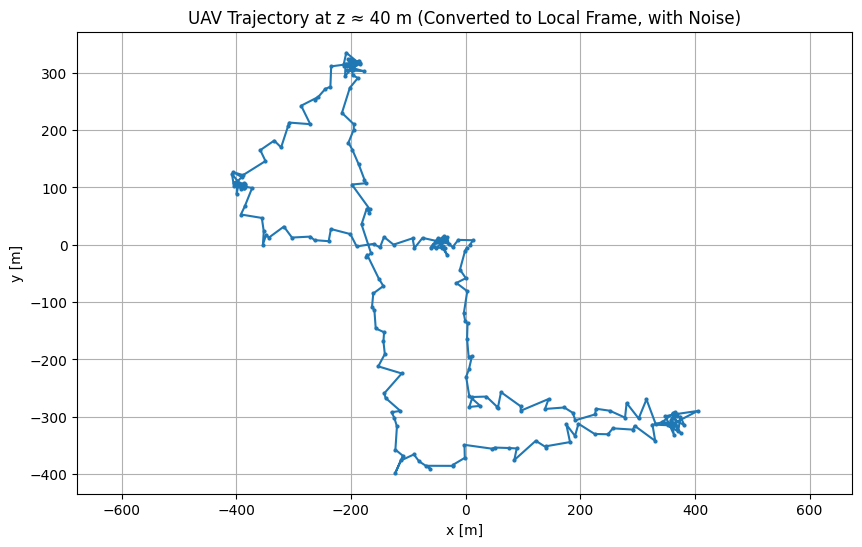

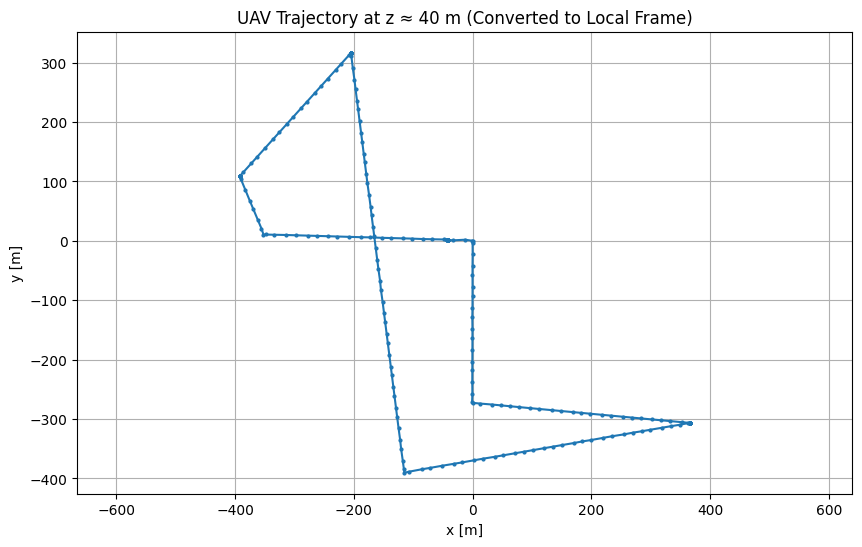

First few rows of the simulation log:
    t     x_true    y_true     x_meas     y_meas
0   0   0.000000  0.000000   7.305034  -0.466298
1   4  -0.361478  0.100188  12.821519   7.976589
2   7 -12.805366  1.870167 -12.778180   8.645147
3  11 -33.012000  0.812632 -22.637441  -3.892127
4  15 -42.970725  1.814508 -40.407710  10.783187

Saved simulation log to: EKF_expo_data/expo1.csv


In [10]:
# Plot with noise
plt.figure(figsize=(10,6))
plt.plot(x_meas, y_meas, '-o', markersize=2)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("UAV Trajectory at z ≈ 40 m (Converted to Local Frame, with Noise)")
plt.grid(True)
plt.axis("equal")
plt.show()
# plot true

plt.figure(figsize=(10,6))
plt.plot(x_true, y_true, '-o', markersize=2)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("UAV Trajectory at z ≈ 40 m (Converted to Local Frame)")
plt.grid(True)
plt.axis("equal")
plt.show()
# plotting time vs sample index


# 5. Save log to CSV for EKF use

# Make sure the output folder exists
os.makedirs("EKF_expo_data", exist_ok=True)

# Build a pandas DataFrame with all the logged data
df2 = pd.DataFrame({
    "t": time_secs,               # time in hr:min:sec format converted to secs.
    "x_true": x_true,     # true x
    "y_true": y_true,     # true y
    "x_meas": x_meas,     # noisy x measurement
    "y_meas": y_meas      # noisy y measurement
})

print("First few rows of the simulation log:")
print(df2.head())

csv_path2 = "EKF_expo_data/expo1.csv"
df2.to_csv(csv_path2, index=True)
print(f"\nSaved simulation log to: {csv_path2}")

In [11]:
# Cell 1: imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# show more decimals if you want
np.set_printoptions(precision=3, suppress=True)

In [12]:
# Cell 2: load data

# adjust path if needed
df = pd.read_csv("EKF_expo_data/expo1.csv")

print(df.head())
print("\nColumns:", df.columns.tolist())

# Extract numpy arrays
t       = df["t"].values          # time [s]
x_true  = df["x_true"].values     # ground-truth x
y_true  = df["y_true"].values     # ground-truth y
x_meas  = df["x_meas"].values     # noisy x
y_meas  = df["y_meas"].values     # noisy y

print("\nLengths:", len(t), len(x_meas), len(y_meas))

   Unnamed: 0   t     x_true    y_true     x_meas     y_meas
0           0   0   0.000000  0.000000   7.305034  -0.466298
1           1   4  -0.361478  0.100188  12.821519   7.976589
2           2   7 -12.805366  1.870167 -12.778180   8.645147
3           3  11 -33.012000  0.812632 -22.637441  -3.892127
4           4  15 -42.970725  1.814508 -40.407710  10.783187

Columns: ['Unnamed: 0', 't', 'x_true', 'y_true', 'x_meas', 'y_meas']

Lengths: 222 222 222


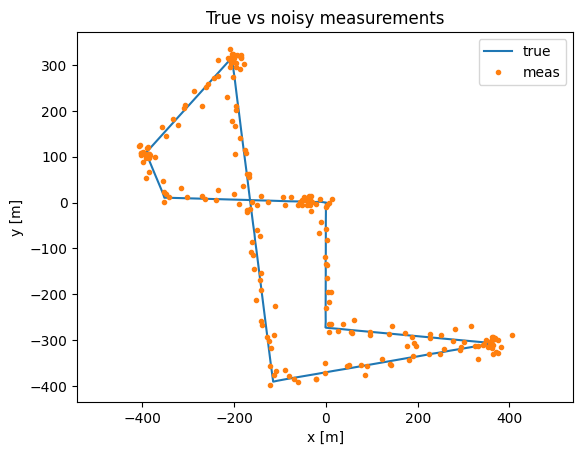

In [13]:
# Cell 3: quick sanity plot of noisy vs true

plt.figure()
plt.plot(x_true, y_true, label="true")
plt.plot(x_meas, y_meas, marker=".", linestyle="none", label="meas")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("True vs noisy measurements")
plt.axis("equal")
plt.show()

In [14]:
# Cell 4: define model matrices (functions because dt changes)

def state_transition_matrix(dt: float) -> np.ndarray:
    """
    F(dt) for constant-velocity model:
    [1 0 dt  0]
    [0 1  0 dt]
    [0 0  1  0]
    [0 0  0  1]
    """
    F = np.array([
        [1.0, 0.0, dt, 0.0],
        [0.0, 1.0, 0.0, dt],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ])
    return F

def measurement_matrix() -> np.ndarray:
    """
    H for measuring position only:
    [1 0 0 0]
    [0 1 0 0]
    """
    H = np.array([
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
    ])
    return H

H = measurement_matrix()

In [15]:
# Cell 5: noise covariances & initial conditions

# Measurement noise: sigma ≈ 10 m | could be an estimate based on sensor specs
sigma_meas = 10.00
R = np.array([
    [sigma_meas**2, 0.0],
    [0.0, sigma_meas**2],
])

# Process noise: tune these
#   small for position, larger for velocity
q_pos = 0.1
q_vel = 1.0
Q = np.diag([q_pos, q_pos, q_vel, q_vel])

# Initial state: start near first measurement
x0 = x_meas[0]
y0 = y_meas[0]

# Rough initial velocity estimate from first two points (or set to 0)
if len(t) >= 2:
    dt0 = max(t[1] - t[0], 1e-6)
    vx0 = (x_meas[1] - x_meas[0]) / dt0
    vy0 = (y_meas[1] - y_meas[0]) / dt0
else:
    vx0 = 0.0
    vy0 = 0.0

x_hat = np.array([x0, y0, vx0, vy0], dtype=float)

# Initial covariance: large uncertainty
P = np.diag([100.0, 100.0, 100.0, 100.0])

print("Initial state x_hat0:", x_hat)
print("Initial covariance P0:\n", P)

Initial state x_hat0: [ 7.305 -0.466  1.379  2.111]
Initial covariance P0:
 [[100.   0.   0.   0.]
 [  0. 100.   0.   0.]
 [  0.   0. 100.   0.]
 [  0.   0.   0. 100.]]


In [16]:
# Cell 6: run the filter

N = len(t)

# storage for filtered states
x_filt_hist = np.zeros((N, 4))  # [x, y, vx, vy] at each step

# save initial state
x_filt_hist[0, :] = x_hat

for k in range(1, N):
    # 1) time step
    dt = t[k] - t[k-1]
    dt = float(dt)
    if dt <= 0:
        dt = 1e-6  # avoid zero / negative dt just in case

    F = state_transition_matrix(dt)

    # 2) PREDICTION STEP
    # x_pred = F x_prev
    x_pred = F @ x_hat

    # P_pred = F P F^T + Q
    P_pred = F @ P @ F.T + Q

    # 3) MEASUREMENT UPDATE
    z_k = np.array([x_meas[k], y_meas[k]])

    # innovation / residual
    y_k = z_k - (H @ x_pred)

    # innovation covariance
    S_k = H @ P_pred @ H.T + R

    # Kalman gain
    K_k = P_pred @ H.T @ np.linalg.inv(S_k)

    # updated state
    x_hat = x_pred + K_k @ y_k

    # updated covariance
    I = np.eye(4)
    P = (I - K_k @ H) @ P_pred

    # store
    x_filt_hist[k, :] = x_hat

# Extract filtered positions
x_filt = x_filt_hist[:, 0]
y_filt = x_filt_hist[:, 1]
vx_filt = x_filt_hist[:, 2]
vy_filt = x_filt_hist[:, 3]

print("Finished filtering.")

Finished filtering.


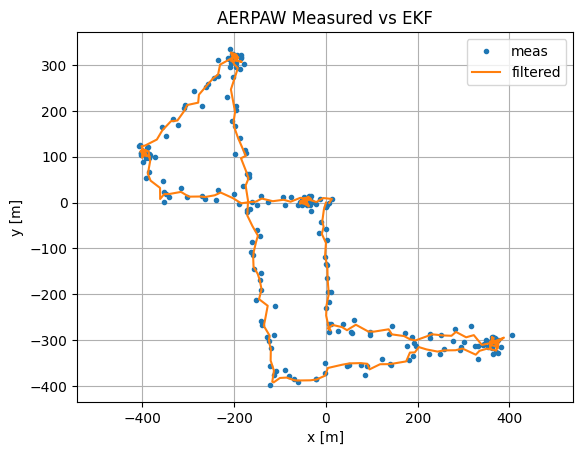

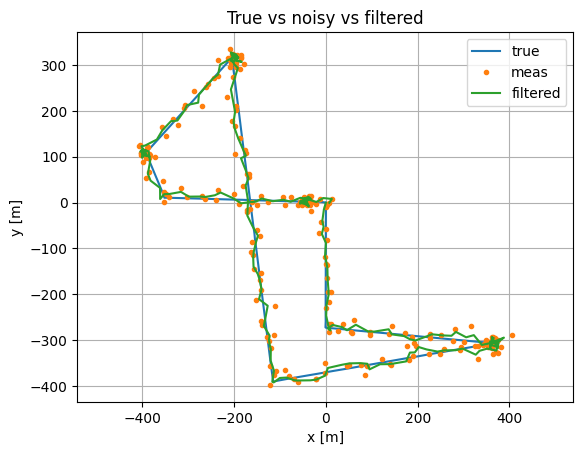

In [17]:
# Cell 7: trajectory comparison

plt.figure()
plt.plot(x_meas, y_meas, marker=".", linestyle="none", label="meas")
plt.plot(x_filt, y_filt, label="filtered")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("AERPAW Measured vs EKF")
plt.axis("equal")
plt.grid()
plt.show()


plt.figure()
plt.plot(x_true, y_true, label="true")
plt.plot(x_meas, y_meas, marker=".", linestyle="none", label="meas")
plt.plot(x_filt, y_filt, label="filtered")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("True vs noisy vs filtered")
plt.axis("equal")
plt.grid()
plt.show()

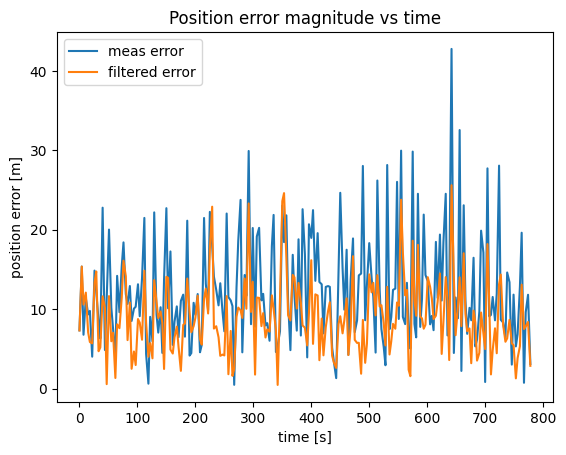

Mean measurement error: 12.396681573159318
Mean filtered error   : 9.015320308771583


In [18]:
# Cell 8: position error over time

err_meas = np.sqrt((x_meas - x_true)**2 + (y_meas - y_true)**2)
err_filt = np.sqrt((x_filt - x_true)**2 + (y_filt - y_true)**2)

plt.figure()
plt.plot(t, err_meas, label="meas error")
plt.plot(t, err_filt, label="filtered error")
plt.xlabel("time [s]")
plt.ylabel("position error [m]")
plt.legend()
plt.title("Position error magnitude vs time")
plt.show()

print("Mean measurement error:", np.mean(err_meas))
print("Mean filtered error   :", np.mean(err_filt))

In [19]:
# Cell 9: wrap the Kalman filter loop into a reusable function

def run_kf_once(t, x_meas, y_meas,
                sigma_meas=10.0,
                q_pos=0.1,
                q_vel=1.0):
    """
    Run a single pass of the constant-velocity Kalman Filter.
    One iteration per time step: predict + update.

    Parameters
    ----------
    t : array-like
        Time stamps [s], length N.
    x_meas, y_meas : array-like
        Noisy position measurements, length N.
    sigma_meas : float
        Standard deviation of measurement noise [m].
    q_pos, q_vel : float
        Process noise levels for position and velocity.

    Returns
    -------
    x_filt_hist : ndarray of shape (N, 4)
        Filtered state history [x, y, vx, vy] at each time step.
    """

    t = np.asarray(t)
    x_meas = np.asarray(x_meas)
    y_meas = np.asarray(y_meas)

    N = len(t)
    assert len(x_meas) == N and len(y_meas) == N, "length mismatch"

    # Measurement matrix (position only)
    H = np.array([
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
    ])

    # Measurement noise covariance
    R = np.array([
        [sigma_meas**2, 0.0],
        [0.0, sigma_meas**2],
    ])

    # Process noise covariance
    Q = np.diag([q_pos, q_pos, q_vel, q_vel])

    # Initial state: use first measurement for position
    x0 = x_meas[0]
    y0 = y_meas[0]

    if N >= 2:
        dt0 = max(t[1] - t[0], 1e-6)
        vx0 = (x_meas[1] - x_meas[0]) / dt0
        vy0 = (y_meas[1] - y_meas[0]) / dt0
    else:
        vx0 = 0.0
        vy0 = 0.0

    x_hat = np.array([x0, y0, vx0, vy0], dtype=float)

    # Initial covariance
    P = np.diag([100.0, 100.0, 100.0, 100.0])

    # storage for all timesteps
    x_filt_hist = np.zeros((N, 4))
    x_filt_hist[0, :] = x_hat

    # ---- MAIN ONE-PASS LOOP: 1 iteration per time step ----
    for k in range(1, N):
        # time step
        dt = float(t[k] - t[k-1])
        if dt <= 0:
            dt = 1e-6

        # State transition matrix for this dt
        F = np.array([
            [1.0, 0.0, dt, 0.0],
            [0.0, 1.0, 0.0, dt],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
        ])

        # --- PREDICT ---
        x_pred = F @ x_hat
        P_pred = F @ P @ F.T + Q

        # --- UPDATE ---
        z_k = np.array([x_meas[k], y_meas[k]])

        y_k = z_k - (H @ x_pred)            # innovation
        S_k = H @ P_pred @ H.T + R          # innovation covariance
        K_k = P_pred @ H.T @ np.linalg.inv(S_k)  # Kalman gain

        x_hat = x_pred + K_k @ y_k         # posterior state
        I = np.eye(4)
        P = (I - K_k @ H) @ P_pred         # posterior covariance

        x_filt_hist[k, :] = x_hat

    return x_filt_hist

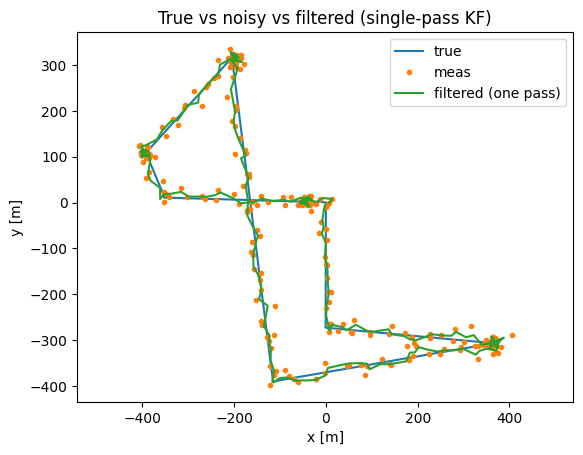

In [20]:
# Cell 10: run one-pass KF and compare to true / noisy

x_filt_hist = run_kf_once(t, x_meas, y_meas,
                          sigma_meas=10.0,
                          q_pos=0.1,
                          q_vel=1.0)

x_filt = x_filt_hist[:, 0]
y_filt = x_filt_hist[:, 1]

plt.figure()
plt.plot(x_true, y_true, label="true")
plt.plot(x_meas, y_meas, marker=".", linestyle="none", label="meas")
plt.plot(x_filt, y_filt, label="filtered (one pass)")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("True vs noisy vs filtered (single-pass KF)")
plt.axis("equal")
plt.show()

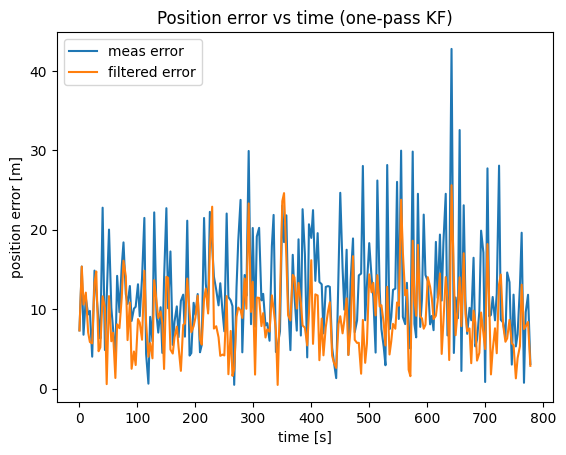

Mean measurement error: 12.396681573159318
Mean filtered error   : 9.015320308771583


In [21]:
# Cell 11: error magnitudes for measurements vs filtered

err_meas = np.sqrt((x_meas - x_true)**2 + (y_meas - y_true)**2)
err_filt = np.sqrt((x_filt - x_true)**2 + (y_filt - y_true)**2)

plt.figure()
plt.plot(t, err_meas, label="meas error")
plt.plot(t, err_filt, label="filtered error")
plt.xlabel("time [s]")
plt.ylabel("position error [m]")
plt.legend()
plt.title("Position error vs time (one-pass KF)")
plt.show()

print("Mean measurement error:", np.mean(err_meas))
print("Mean filtered error   :", np.mean(err_filt))

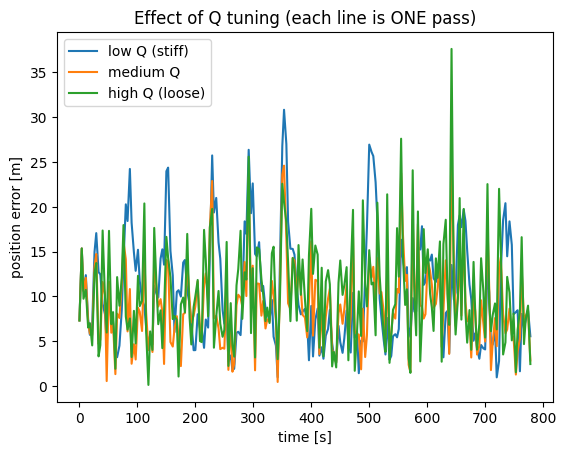

In [22]:
# Cell 12: compare different process noise (still one pass each)

configs = [
    {"label": "low Q (stiff)", "q_pos": 0.01, "q_vel": 0.1},
    {"label": "medium Q",      "q_pos": 0.1,  "q_vel": 1.0},
    {"label": "high Q (loose)", "q_pos": 1.0, "q_vel": 10.0},
]

plt.figure()

for cfg in configs:
    x_hist_cfg = run_kf_once(t, x_meas, y_meas,
                             sigma_meas=10.0,
                             q_pos=cfg["q_pos"],
                             q_vel=cfg["q_vel"])
    x_f = x_hist_cfg[:, 0]
    y_f = x_hist_cfg[:, 1]

    err_cfg = np.sqrt((x_f - x_true)**2 + (y_f - y_true)**2)
    plt.plot(t, err_cfg, label=cfg["label"])

plt.xlabel("time [s]")
plt.ylabel("position error [m]")
plt.legend()
plt.title("Effect of Q tuning (each line is ONE pass)")
plt.show()